In [1]:
import torch
import torch.nn as nn
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

In [2]:
root_dir = '/kaggle/input/crocodilo/new_fer2013_cropped/train'
classes = {
    label_idx: class_name \
        for label_idx, class_name in enumerate(
            sorted(os.listdir(root_dir))
        )
}

In [3]:
classes

{0: 'angry',
 1: 'disgust',
 2: 'fear',
 3: 'happy',
 4: 'neutral',
 5: 'sad',
 6: 'surprise'}

In [4]:
dataset_path = '/kaggle/input/crocodilo/new_fer2013_cropped'

In [5]:
transform_train = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),  
    transforms.RandomResizedCrop(224, scale=(0.8, 1.2)), 
    transforms.RandomApply([transforms.ColorJitter(
        brightness=0.5, contrast=0.5, saturation=0.5)], p=0.5),
    transforms.RandomApply([transforms.RandomAffine(0, translate=(0.2, 0.2))], p=0.5),
    transforms.RandomHorizontalFlip(),
    transforms.RandomApply([transforms.RandomRotation(10)], p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485], std=[0.229]), 
    transforms.RandomErasing()
]) 

transform_test = transforms.Compose([
    transforms.Grayscale(num_output_channels=3), 
    transforms.Resize(224), 
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485], std=[0.229]), 
])

In [6]:
train_dataset = datasets.ImageFolder(root=f"{dataset_path}/train", transform=transform_train)
val_dataset = datasets.ImageFolder(root=f"{dataset_path}/val", transform=transform_test)
test_dataset = datasets.ImageFolder(root=f"{dataset_path}/test", transform=transform_test)

In [7]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [8]:
train_labels = train_dataset.targets  
class_indices = list(range(len(classes)))
class_weights = compute_class_weight(
    'balanced', 
    classes=class_indices, 
    y=train_labels
)

In [9]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

Feature batch shape: torch.Size([64, 3, 224, 224])
Labels batch shape: torch.Size([64])


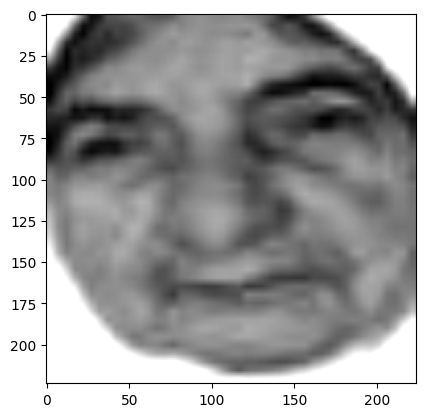

In [10]:
train_features, train_labels = next(iter(train_loader))

print(f'Feature batch shape: {train_features.size()}')
print(f'Labels batch shape: {train_labels.size()}')

img = train_features[5]
img = img.permute(1, 2, 0)

mean = [0.485]
std = [0.229]

img = img * torch.tensor(std) + torch.tensor(mean)
img = img.clamp(0, 1)

plt.imshow(img.numpy())  
plt.show()

In [11]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

num_ftrs = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_ftrs, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(128, 7)
)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 168MB/s] 


In [12]:
epochs = 100 
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.001,
    momentum=0.9,
    weight_decay=0.0001
)
scheduler = CosineAnnealingLR(optimizer, T_max=100, eta_min=0)

In [13]:
def evaluate_train(model, loader, criterion, device):
    model.eval()
    correct = 0
    total = 0
    loss_total = 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss_total += loss.item() * inputs.size(0)
            
            _, predicted = torch.max(outputs.data, 1)
            
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    loss = loss_total / total
    acc = correct / total

    return loss, acc

In [14]:
class_names = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

In [15]:
train_losses = []
val_losses = []
train_accs = []
val_accs = []
best_val_acc = 0.0
epochs_without_improvement = 0 

for epoch in range(epochs):
    train_loss = 0.0
    train_correct = 0
    total_samples = 0

    model.train()
    for idx, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * inputs.size(0)
        train_correct += (torch.argmax(outputs, 1) == labels).sum().item()
        total_samples += labels.size(0)

    train_loss /= total_samples
    train_acc = train_correct / total_samples
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    val_loss, val_acc = evaluate_train(model, val_loader, criterion, device)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    scheduler.step()

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), '/kaggle/working/best_model.pth') 
        print(f'Best model saved with val acc: {val_acc:.4f}')

    print(f'EPOCH {epoch + 1}/{epochs}:\tTrain loss: {train_loss:.4f}\tVal loss: {val_loss:.4f}\tTrain accuracy: {train_acc:.4f}\tVal accuracy: {val_acc:.4f}')


Best model saved with val acc: 0.2152
EPOCH 1/100:	Train loss: 1.9642	Val loss: 1.9302	Train accuracy: 0.1524	Val accuracy: 0.2152
Best model saved with val acc: 0.2332
EPOCH 2/100:	Train loss: 1.9387	Val loss: 1.8852	Train accuracy: 0.1817	Val accuracy: 0.2332
Best model saved with val acc: 0.3161
EPOCH 3/100:	Train loss: 1.8669	Val loss: 1.7901	Train accuracy: 0.2219	Val accuracy: 0.3161
Best model saved with val acc: 0.3439
EPOCH 4/100:	Train loss: 1.8189	Val loss: 1.7645	Train accuracy: 0.2469	Val accuracy: 0.3439
Best model saved with val acc: 0.3725
EPOCH 5/100:	Train loss: 1.7897	Val loss: 1.7114	Train accuracy: 0.2557	Val accuracy: 0.3725
EPOCH 6/100:	Train loss: 1.7559	Val loss: 1.6624	Train accuracy: 0.2899	Val accuracy: 0.3420
Best model saved with val acc: 0.4067
EPOCH 7/100:	Train loss: 1.6961	Val loss: 1.4724	Train accuracy: 0.3258	Val accuracy: 0.4067
Best model saved with val acc: 0.4634
EPOCH 8/100:	Train loss: 1.6157	Val loss: 1.3588	Train accuracy: 0.3633	Val accurac

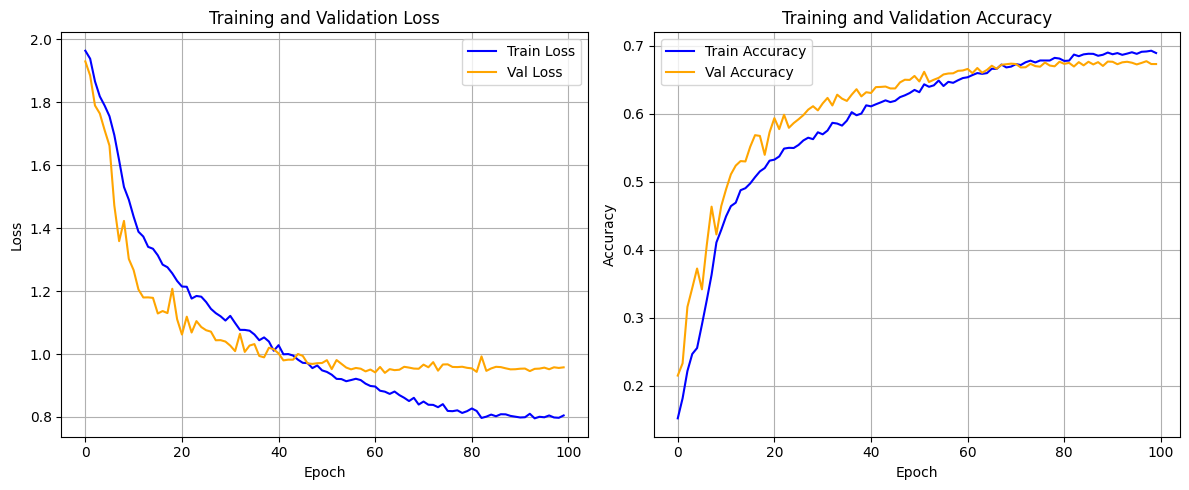

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].plot(train_losses, color='blue', label='Train Loss')
ax[0].plot(val_losses, color='orange', label='Val Loss')
ax[0].set_title('Training and Validation Loss')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].legend()
ax[0].grid(True)

ax[1].plot(train_accs, color='blue', label='Train Accuracy')
ax[1].plot(val_accs, color='orange', label='Val Accuracy')
ax[1].set_title('Training and Validation Accuracy')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy')
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()


In [17]:
model.load_state_dict(torch.load(r"/kaggle/working/best_model.pth", map_location=device))

<All keys matched successfully>

In [18]:
val_loss, val_acc = evaluate_train(
    model,
    val_loader,
    criterion,
    device,
)
test_loss, test_acc = evaluate_train(
    model,
    test_loader,
    criterion,
    device,
)

print('Evaluation on val/test dataset')
print('Val accuracy: ', val_acc)
print('Test accuracy: ', test_acc)

Evaluation on val/test dataset
Val accuracy:  0.677231025854879
Test accuracy:  0.6717340461075844


In [19]:
def compute_classwise_metrics(y_true, y_pred, num_classes):
    precision = precision_score(y_true, y_pred, average=None, labels=np.arange(num_classes))
    recall = recall_score(y_true, y_pred, average=None, labels=np.arange(num_classes))
    f1 = f1_score(y_true, y_pred, average=None, labels=np.arange(num_classes))
    return precision, recall, f1

def plot_confusion_matrix(cm, classes):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.title('Confusion Matrix')
    plt.show()

def evaluate_test(model, test_loader, criterion, device, num_classes):
    model.eval()
    y_true = []
    y_pred = []
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy()) 
    
    precision, recall, f1 = compute_classwise_metrics(np.array(y_true), np.array(y_pred), num_classes)

    return precision, recall, f1, y_true, y_pred


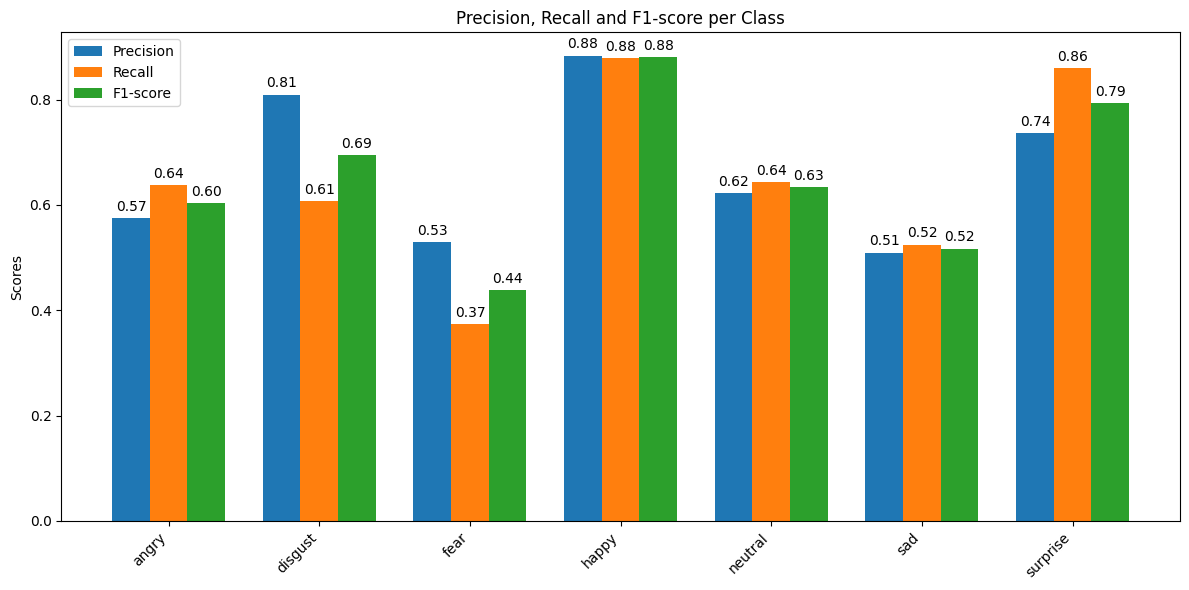

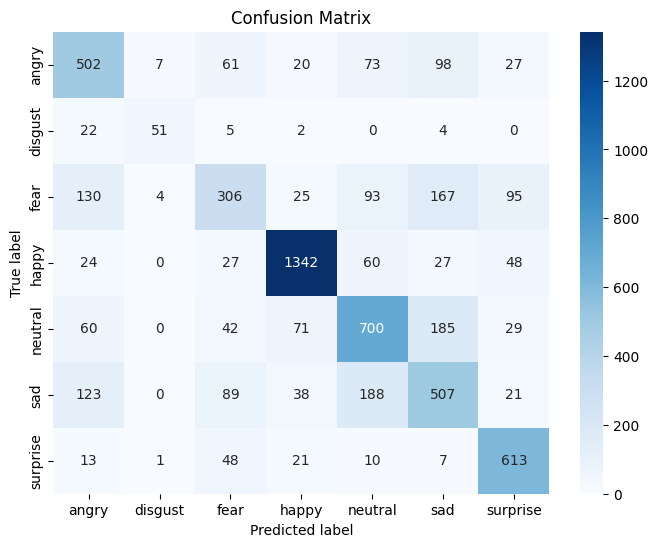

In [20]:
test_precision, test_recall, test_f1, y_true, y_pred = evaluate_test(
    model, 
    test_loader,
    criterion,
    device,
    len(class_names)
)

data = {
    'precision': [test_precision[i] for i in range(len(class_names))],
    'recall': [test_recall[i] for i in range(len(class_names))],
    'f1': [test_f1[i] for i in range(len(class_names))]
}
df = pd.DataFrame(data, index=class_names)

labels = class_names
x = np.arange(len(labels)) 
width = 0.25  

fig, ax = plt.subplots(figsize=(12,6))
rects1 = ax.bar(x - width, df['precision'], width, label='Precision')
rects2 = ax.bar(x, df['recall'], width, label='Recall')
rects3 = ax.bar(x + width, df['f1'], width, label='F1-score')

ax.set_ylabel('Scores')
ax.set_title('Precision, Recall and F1-score per Class')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.legend()

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), 
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

plt.tight_layout()
plt.show()

print('\n\n')

cm = confusion_matrix(np.array(y_true), np.array(y_pred)) 
plot_confusion_matrix(cm, class_names)